# Step 1. 단변량 분포 확인 (Univariate EDA)

경기도 카드소비 x 날씨 데이터 EDA 1단계.
목표: 매출 관련 변수와 날씨 변수 각각의 분포를 확인하고, 이상치/왜도/로그변환 필요 여부를 판단한다.

In [1]:
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# 한글 폰트 설정 (OS별 자동 분기)
system = platform.system()
if system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

pd.set_option("display.max_columns", None)
%matplotlib inline

In [2]:
from pathlib import Path

# 프로젝트 루트 기준 경로. notebooks/ 폴더에서 실행 중이면 "../data/..."로 바꾸세요.
DATA_PATH = Path("../../data/processed/consume_weather_merged.parquet")

df = pd.read_parquet(DATA_PATH)
print("shape:", df.shape)
df.head()

shape: (3424851, 14)


,날짜,대분류,소분류,연령 그룹,매출금액,매출건수,건당 매출금액,도시,지점명,date,평균기온(°C),일강수량(mm),평균 풍속(m/s),일 최심적설(cm)
0,20220101,공공/기업/단체,공공기관,2,888426,185,4802.30,포천시,북부,2022-01-01,-6.4,0.0,0.7,0.0
1,20220101,공공/기업/단체,공공기관,3,2027838,314,6458.08,포천시,북부,2022-01-01,-6.4,0.0,0.7,0.0
2,20220101,공공/기업/단체,공공기관,4,8361,5,1672.20,포천시,북부,2022-01-01,-6.4,0.0,0.7,0.0
3,20220101,공공/기업/단체,기업,1,362709,8,45338.62,포천시,북부,2022-01-01,-6.4,0.0,0.7,0.0
4,20220101,공공/기업/단체,기업,2,7821763,171,45741.30,포천시,북부,2022-01-01,-6.4,0.0,0.7,0.0


## 1-0. 기본 정보 확인

In [3]:
print(df.dtypes)
print()
print("기간:", df["date"].min(), "~", df["date"].max())
print("도시:", sorted(df["도시"].unique()))
print("권역:", sorted(df["지점명"].unique()))
print("연령그룹:", sorted(df["연령 그룹"].unique()))
print()
print("결측치:")
print(df.isna().sum())

날짜                     int64
대분류                      str
소분류                      str
연령 그룹                  int64
매출금액                   int64
매출건수                   int64
건당 매출금액              float64
도시                       str
지점명                      str
date          datetime64[us]
평균기온(°C)             float64
일강수량(mm)             float64
평균 풍속(m/s)           float64
일 최심적설(cm)           float64
dtype: object

기간: 2022-01-01 00:00:00 ~ 2025-12-31 00:00:00
도시: ['광명시', '수원시', '시흥시', '안산시', '안양시', '용인시', '포천시', '하남시', '화성시']
권역: ['남부', '동부', '북부']
연령그룹: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

결측치:
날짜             0
대분류            0
소분류            0
연령 그룹          0
매출금액           0
매출건수           0
건당 매출금액       11
도시             0
지점명            0
date           0
평균기온(°C)       0
일강수량(mm)       0
평균 풍속(m/s)     0
일 최심적설(cm)     0
dtype: int64


## 1-1. 매출금액 분포

카드 소비 데이터는 소수 초고액 결제 때문에 오른쪽 꼬리가 긴 분포가 흔하다.
원본 분포와 로그변환 분포를 같이 확인해서, 이후 분석(상관/회귀)에서 로그변환이 필요한지 판단한다.

count    3.424851e+06
mean     6.548917e+07
std      2.564487e+08
min      0.000000e+00
25%      5.386755e+05
50%      4.842004e+06
75%      3.620170e+07
max      1.194895e+10
Name: 매출금액, dtype: float64

왜도(skewness): 11.473432892392871


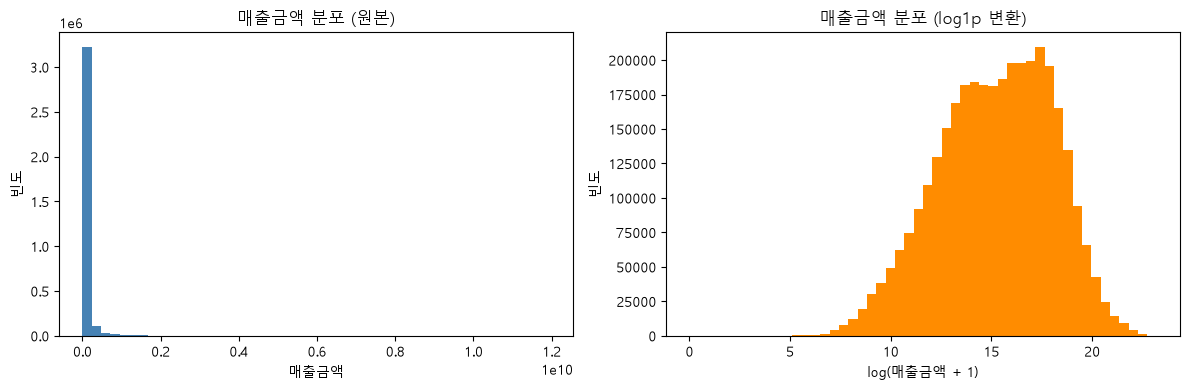

In [4]:
print(df["매출금액"].describe())
print()
print("왜도(skewness):", df["매출금액"].skew())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["매출금액"], bins=50, color="steelblue")
axes[0].set_title("매출금액 분포 (원본)")
axes[0].set_xlabel("매출금액")
axes[0].set_ylabel("빈도")

axes[1].hist(np.log1p(df["매출금액"]), bins=50, color="darkorange")
axes[1].set_title("매출금액 분포 (log1p 변환)")
axes[1].set_xlabel("log(매출금액 + 1)")
axes[1].set_ylabel("빈도")

plt.tight_layout()
plt.show()

## 1-2. 매출건수 분포

count    3.424851e+06
mean     1.980623e+03
std      9.293066e+03
min      0.000000e+00
25%      2.000000e+01
50%      1.240000e+02
75%      8.710000e+02
max      2.712110e+05
Name: 매출건수, dtype: float64

왜도(skewness): 12.508469992541306


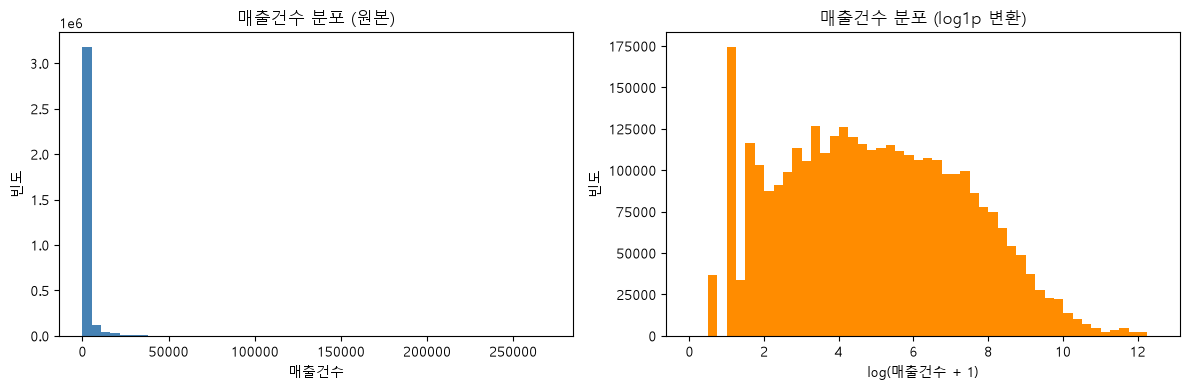

In [5]:
print(df["매출건수"].describe())
print()
print("왜도(skewness):", df["매출건수"].skew())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["매출건수"], bins=50, color="steelblue")
axes[0].set_title("매출건수 분포 (원본)")
axes[0].set_xlabel("매출건수")
axes[0].set_ylabel("빈도")

axes[1].hist(np.log1p(df["매출건수"]), bins=50, color="darkorange")
axes[1].set_title("매출건수 분포 (log1p 변환)")
axes[1].set_xlabel("log(매출건수 + 1)")
axes[1].set_ylabel("빈도")

plt.tight_layout()
plt.show()

## 1-3. 건당 매출금액(단가) 분포

count    3.424840e+06
mean     8.331138e+04
std      3.133606e+05
min      0.000000e+00
25%      1.315500e+04
50%      2.924091e+04
75%      6.435395e+04
max      9.418939e+07
Name: 건당 매출금액, dtype: float64

왜도(skewness): 45.29813100183097


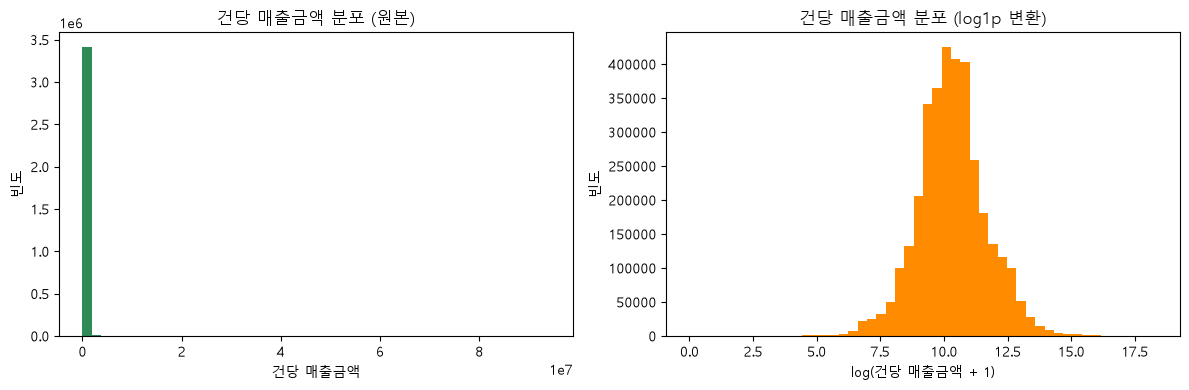

In [ ]:
print(df["건당 매출금액"].describe())
print()
print("왜도(skewness):", df["건당 매출금액"].skew())


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["건당 매출금액"], bins=50, color="seagreen")
axes[0].set_title("건당 매출금액 분포 (원본)")
axes[0].set_xlabel("건당 매출금액")
axes[0].set_ylabel("빈도")

axes[1].hist(np.log1p(df["건당 매출금액"]), bins=50, color="darkorange")
axes[1].set_title("건당 매출금액 분포 (log1p 변환)")
axes[1].set_xlabel("log(건당 매출금액 + 1)")
axes[1].set_ylabel("빈도")

plt.tight_layout()
plt.show()

## 1-4. 이상치 스캔

음수이거나 비정상적으로 극단적인 값이 있는지 확인한다 (있다면 데이터 오류 가능성).

In [7]:
for col in ["매출금액", "매출건수", "건당 매출금액"]:
    n_negative = (df[col] < 0).sum()
    q99 = df[col].quantile(0.99)
    q999 = df[col].quantile(0.999)
    print(f"[{col}] 음수: {n_negative}건, 99% 분위: {q99:,.0f}, 99.9% 분위: {q999:,.0f}, 최대값: {df[col].max():,.0f}")

[매출금액] 음수: 0건, 99% 분위: 1,055,459,754, 99.9% 분위: 3,387,786,096, 최대값: 11,948,948,791
[매출건수] 음수: 0건, 99% 분위: 30,030, 99.9% 분위: 153,707, 최대값: 271,211
[건당 매출금액] 음수: 0건, 99% 분위: 814,643, 99.9% 분위: 3,916,724, 최대값: 94,189,394


## 1-5. 날씨 변수 분포

           평균기온(°C)      일강수량(mm)    평균 풍속(m/s)    일 최심적설(cm)
count  3.424851e+06  3.424851e+06  3.424851e+06  3.424851e+06
mean   1.338957e+01  3.840282e+00  1.758669e+00  1.020034e-01
std    1.058279e+01  1.274037e+01  7.343873e-01  5.569550e-01
min   -1.280000e+01  0.000000e+00  2.000000e-01  0.000000e+00
25%    4.200000e+00  0.000000e+00  1.200000e+00  0.000000e+00
50%    1.460000e+01  0.000000e+00  1.700000e+00  0.000000e+00
75%    2.290000e+01  4.000000e-01  2.200000e+00  0.000000e+00
max    3.066180e+01  1.066540e+02  4.761800e+00  4.018000e+00


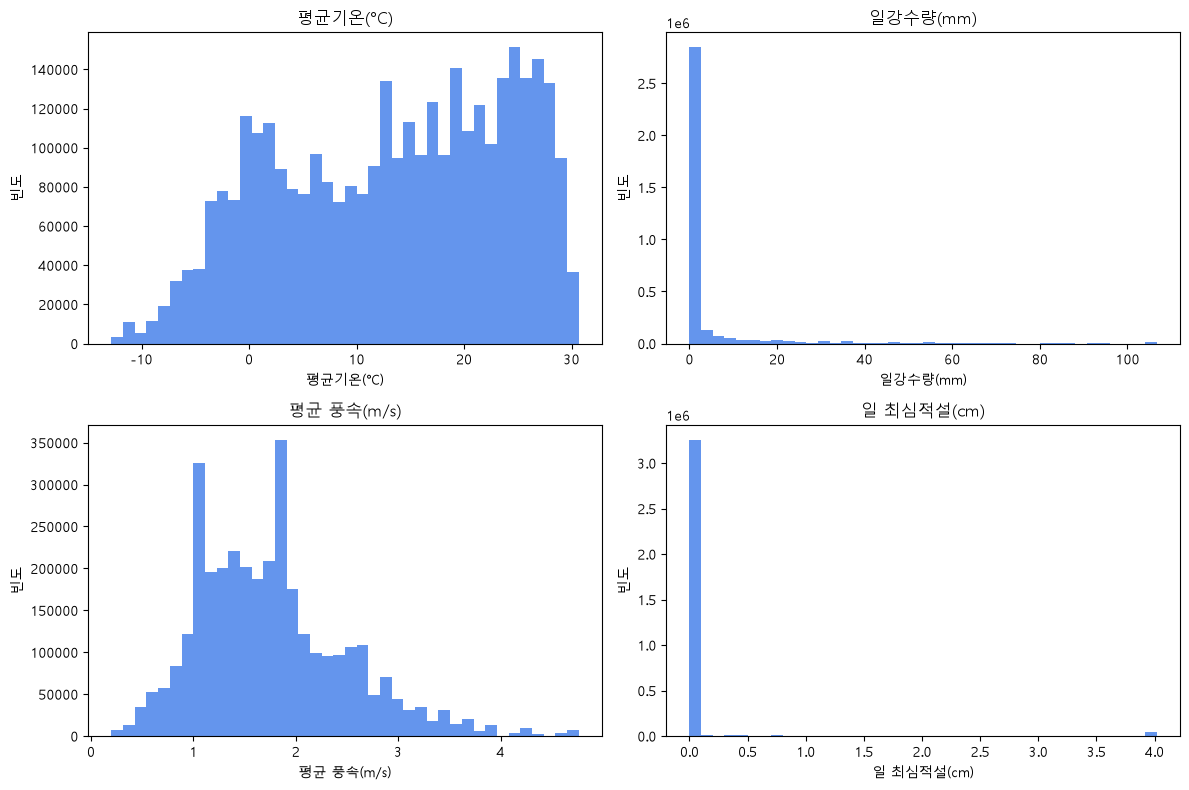

In [8]:
weather_cols = ["평균기온(°C)", "일강수량(mm)", "평균 풍속(m/s)", "일 최심적설(cm)"]

print(df[weather_cols].describe())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, weather_cols):
    ax.hist(df[col], bins=40, color="cornflowerblue")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("빈도")

plt.tight_layout()
plt.show()

## 1단계 요약 (직접 채워넣기)

- 매출금액/매출건수: 왜도 확인 결과 로그변환이 [필요 / 불필요]하다고 판단됨
- 이상치: [있음 / 없음], 있다면 처리 방향: ...
- 날씨 변수: 특이사항 ...

다음 단계(2단계: 시계열 트렌드)로 이동.